In [1]:
# Cell 1: Setup

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import math

# GPU configuration: allow memory growth and enable XLA JIT compilation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)

# Mixed precision: conv/dense ops run in float16, weights stay float32
keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Compute dtype: {keras.mixed_precision.global_policy().compute_dtype}")

np.random.seed(42)
tf.random.set_seed(42)

LATENT_DIM  = 32
KL_WEIGHT   = 1.0
BATCH_SIZE  = 256
LEARNING_RATE = 0.003
WEIGHT_DECAY  = 0.0005
CLIPNORM      = 2.0
EPOCHS        = 100

AES_START_EPOCH   = int(EPOCHS * 0.3)
AES_SENSITIVITY   = 0.075
LR_DECAY_FACTOR   = EPOCHS * 0.015
MODEL_START_EPOCH = int(EPOCHS * 0.35)
WARMUP_EPOCHS     = EPOCHS // 20
STAGE_EPOCHS      = int(EPOCHS * 0.3)
FREEZE_RATIO      = 0.5

BASE_FILTERS   = 16
MAX_LAYERS     = 4
BOTTLENECK_DIM = 4

IMAGE_SIZE_X = 32
IMAGE_SIZE_Y = 32
CHANNELS     = 3
STRIDE       = 2

2026-04-25 01:53:02.308792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 01:53:02.995965: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-25 01:53:05.365618: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16


In [2]:
# Cell 2: Architecture

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon


def build_encoder(num_layers, latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
    x = inputs
    
    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = min(num_layers, max_down)

    for i in range(num_layers):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < num_down else 1
        
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    
    z_mean    = layers.Conv2D(latent_dim, 1, name='z_mean')(x)
    z_log_var = layers.Conv2D(latent_dim, 1, name='z_log_var')(x)
    z         = Sampling()([z_mean, z_log_var])

    return keras.Model(inputs, [z_mean, z_log_var, z], name=f'encoder_L{num_layers}')


def build_decoder(num_layers, latent_dim=LATENT_DIM):
    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = min(num_layers, max_down)

    current_size = IMAGE_SIZE_X // (2 ** num_down)

    inputs = keras.Input(shape=(current_size, current_size, latent_dim))
    x = inputs

    for i in range(num_layers - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < num_down else 1
        
        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh', dtype='float32')(x)
    
    return keras.Model(inputs, outputs, name=f'decoder_L{num_layers}')


# Freezing function targets early encoder layers and late decoder layers
# Increase freeze_ratio for more aggressive freezing of layers (0.5 = half the layers frozen)
def freeze_layers(encoder, decoder, freeze_ratio=FREEZE_RATIO):     
    enc_layers = encoder.layers
    dec_layers = decoder.layers

    enc_cut = int(len(enc_layers) * freeze_ratio)
    dec_cut = int(len(dec_layers) * freeze_ratio)

    # Freeze early encoder layers
    for layer in enc_layers[:enc_cut]:
        layer.trainable = False

    # Freeze late decoder layers
    for layer in dec_layers[-dec_cut:]:
        layer.trainable = False


# Weight transfer function for progressive learning between stages
def transfer_weights(old_model, new_model):
    for new_layer in new_model.layers:
        try:
            old_layer = old_model.get_layer(new_layer.name)
            new_layer.set_weights(old_layer.get_weights())
        except:
            continue


class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight_var, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight_var = tf.Variable(kl_weight_var, trainable=False, dtype=tf.float32)

        # Metric trackers so val_recon_loss / val_kl_loss appear in logs
        # Averaged over whole epoch too instead of just showing the last batch's recon/kl loss
        self._loss_tracker       = keras.metrics.Mean(name='loss')
        self._recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self._kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property       # Makes metrics act like a variable so Keras can find and reset them each epoch
    def metrics(self):
        return [self._loss_tracker, self._recon_loss_tracker, self._kl_loss_tracker]

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        # Cast to float32 as mixed precision can produce float16 tensors
        x              = tf.cast(x,              tf.float32)
        reconstruction = tf.cast(reconstruction, tf.float32)
        z_mean         = tf.cast(z_mean,         tf.float32)
        z_log_var      = tf.cast(z_log_var,      tf.float32)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )
        # reduce_sum over axis=1 (latent dims) first, then mean over batch
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=[1, 2, 3])   # spatial + channels
        )
        total_loss = recon_loss + tf.cast(self.kl_weight_var, tf.float32) * kl_loss
        return total_loss, recon_loss, kl_loss

    def _update_metrics(self, total, recon, kl):
        self._loss_tracker.update_state(total)
        self._recon_loss_tracker.update_state(recon)
        self._kl_loss_tracker.update_state(kl)
        return {
            'loss':       self._loss_tracker.result(),
            'recon_loss': self._recon_loss_tracker.result(),
            'kl_loss':    self._kl_loss_tracker.result(),
        }

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update_metrics(total, recon, kl)

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        return self._update_metrics(total, recon, kl)


encoder = build_encoder(num_layers=MAX_LAYERS, latent_dim=LATENT_DIM)
decoder = build_decoder(num_layers=MAX_LAYERS, latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight_var=KL_WEIGHT, name='vae')
print('VAE built.')

I0000 00:00:1777078387.720843 1048044 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built.


In [ ]:
# Cell 3: Custom Callbacks

# KL annealing: gradually increases KL weight from 0 to 1 over a number of epochs with a smooth sigmoid curve
class KLAnneal(keras.callbacks.Callback):
    def __init__(self, weight_target=KL_WEIGHT, warmup_epochs=WARMUP_EPOCHS, steepness=0.2, verbose=True):
        super().__init__()
        self.kl_weight_target = weight_target
        self.warmup_epochs    = warmup_epochs
        self.steepness        = steepness
        self.verbose          = verbose
        
    def on_epoch_begin(self, epoch, logs=None):         
        midpoint = self.warmup_epochs / 2
        progress = (epoch - midpoint) / (self.steepness * self.warmup_epochs)
        new_weight = self.kl_weight_target / (1.0 + math.exp(-progress))
        self.model.kl_weight_var.assign(new_weight)
        if self.verbose and self.kl_weight_target < new_weight:
            print(f'\n[KL Annealing] Epoch {epoch + 1}: KL weight set to {new_weight:.4f}.')

# ModelCheckpoint that only starts saving after a certain number of epochs to avoid saving useless checkpoints during early unstable training phases
class DelayedModelCheckpoint(keras.callbacks.ModelCheckpoint):
    def __init__(self, *args, start_epoch=0, **kwargs):
        super().__init__(*args, **kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        super().on_epoch_end(epoch, logs)

In [ ]:
# Cell 4: Data Pipeline

(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = (x_train.astype('float32') / 127.5) - 1.0
x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f'Training data: {x_train.shape}')
print(f'Test data:     {x_test.shape}')

@tf.function        # Decorator compiles this function into a TensorFlow graph for better performance when used in the data pipeline
def augment(x, y):      # Augmentation function that applies random transformations to the input images to improve generalization. The target (y) is ignored since this is an autoencoder.
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)   # adds richer variety to training images
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x, -1.0, 1.0)                # keep values in valid [-1, 1] range after augmentation
    return x, x

train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, x_train))
    .cache()                          # keeps dataset in RAM after epoch 1
    .shuffle(len(x_train))            # full-dataset shuffle for proper random batches
    .batch(BATCH_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, x_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# Callbacks:

print_lr = keras.callbacks.LambdaCallback(on_epoch_end=lambda epoch, logs: print(f"\n[Learning Rate: {float(vae.optimizer.learning_rate):.2e}]"))

kl_anneal = KLAnneal(weight_target=KL_WEIGHT, warmup_epochs=STAGE_EPOCHS // 2, verbose=True)

checkpoint = DelayedModelCheckpoint(
    'vae_best.weights.h5',
    start_epoch=MODEL_START_EPOCH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

csv_logger = keras.callbacks.CSVLogger('training_log.csv', append=False)


histories = []

previous_encoder = None
previous_decoder = None

for stage_layers in range(1, MAX_LAYERS + 1):

    print(f"\nTraining Stage: {stage_layers}\n")

    encoder = build_encoder(stage_layers)
    decoder = build_decoder(stage_layers)
    vae     = VAE(encoder, decoder, kl_weight_var=KL_WEIGHT)

    # Transfer weights from previous stage
    if previous_encoder is not None:
        transfer_weights(previous_encoder, encoder)
        transfer_weights(previous_decoder, decoder)
        freeze_layers(encoder, decoder, freeze_ratio=FREEZE_RATIO)

    # Cosine-decay LR schedule with linear warm-up
    steps_per_epoch = len(x_train) // BATCH_SIZE
    total_steps  = steps_per_epoch * EPOCHS
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS

    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE / 10,  # start lower for warm-up
        decay_steps=total_steps * LR_DECAY_FACTOR,  # slow down decay to give AES more time to work
        alpha=1e-6,          # minimum LR at end of cosine decay
        warmup_target=LEARNING_RATE,
        warmup_steps=warmup_steps,
    )
    # Re-compile with scheduled LR
    lr_optimizer = keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=WEIGHT_DECAY,
        clipnorm=CLIPNORM,
    )
    
    vae.compile(optimizer=lr_optimizer)

    # Build model first once or checkpoint callback will break 
    vae(tf.zeros((1, IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS)))
    print('Starting training.')
    
    # Train
    history = vae.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=STAGE_EPOCHS,
        verbose=2,
        callbacks=[print_lr, kl_anneal, csv_logger]
    )

    # Save models for next stage
    previous_encoder = encoder
    previous_decoder = decoder

    # Append history for visualisations later
    histories.append(history.history)

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)

Training Stage: 1



2026-04-25 01:53:14.524421: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-04-25 01:53:14.588843: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Starting training.
Epoch 1/30


2026-04-25 01:53:19.878564: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f48f8004150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-25 01:53:19.878620: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1777078399.982401 1048137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-25 01:53:21.419708: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.



[Learning Rate: 8.43e-04]
196/196 - 20s - 102ms/step - kl_loss: 2801.7336 - loss: 833.9240 - recon_loss: 621.3898 - val_kl_loss: 491.3201 - val_loss: 383.6894 - val_recon_loss: 346.4187
Epoch 2/30

[Learning Rate: 1.39e-03]
196/196 - 2s - 8ms/step - kl_loss: 949.0979 - loss: 268.9328 - recon_loss: 171.3807 - val_kl_loss: 639.0118 - val_loss: 215.3066 - val_recon_loss: 149.6264
Epoch 3/30

[Learning Rate: 1.93e-03]
196/196 - 2s - 8ms/step - kl_loss: 578.4145 - loss: 227.8076 - recon_loss: 148.0780 - val_kl_loss: 562.7635 - val_loss: 211.6497 - val_recon_loss: 134.0775
Epoch 4/30

[Learning Rate: 2.47e-03]
196/196 - 2s - 8ms/step - kl_loss: 440.2949 - loss: 230.3392 - recon_loss: 150.0183 - val_kl_loss: 417.6126 - val_loss: 206.2497 - val_recon_loss: 130.0665
Epoch 5/30

[Learning Rate: 3.00e-03]
196/196 - 2s - 8ms/step - kl_loss: 342.3849 - loss: 214.9625 - recon_loss: 133.6606 - val_kl_loss: 353.0642 - val_loss: 196.2177 - val_recon_loss: 112.3797
Epoch 6/30

[Learning Rate: 3.00e-03]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


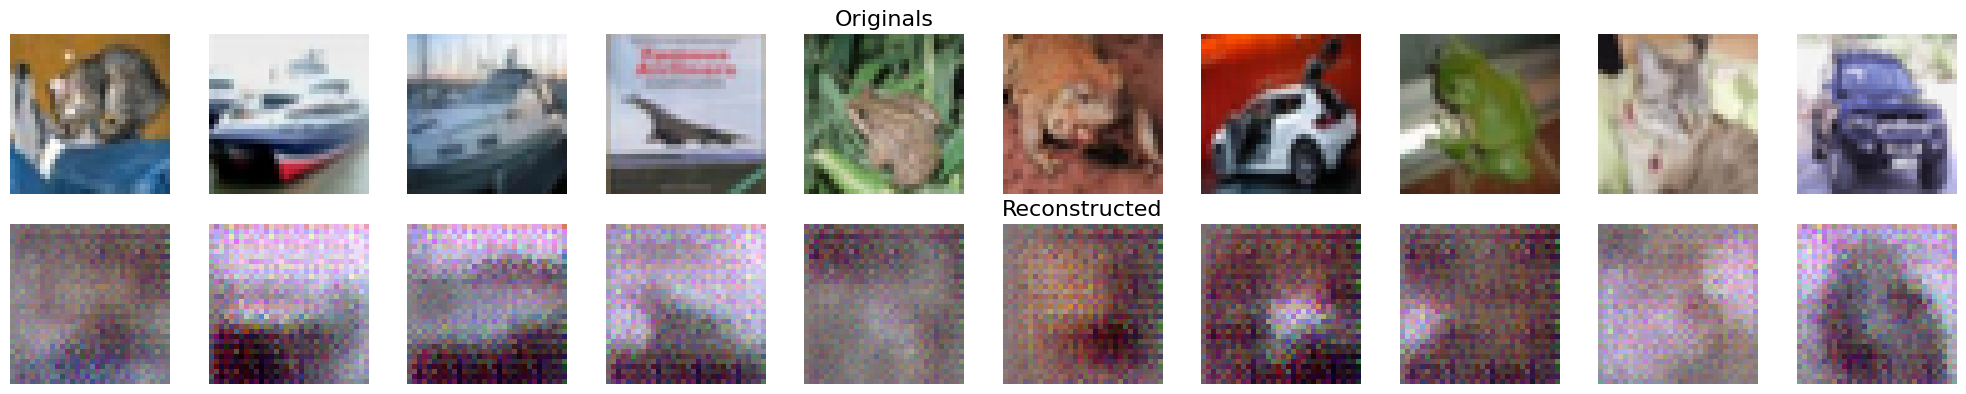

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


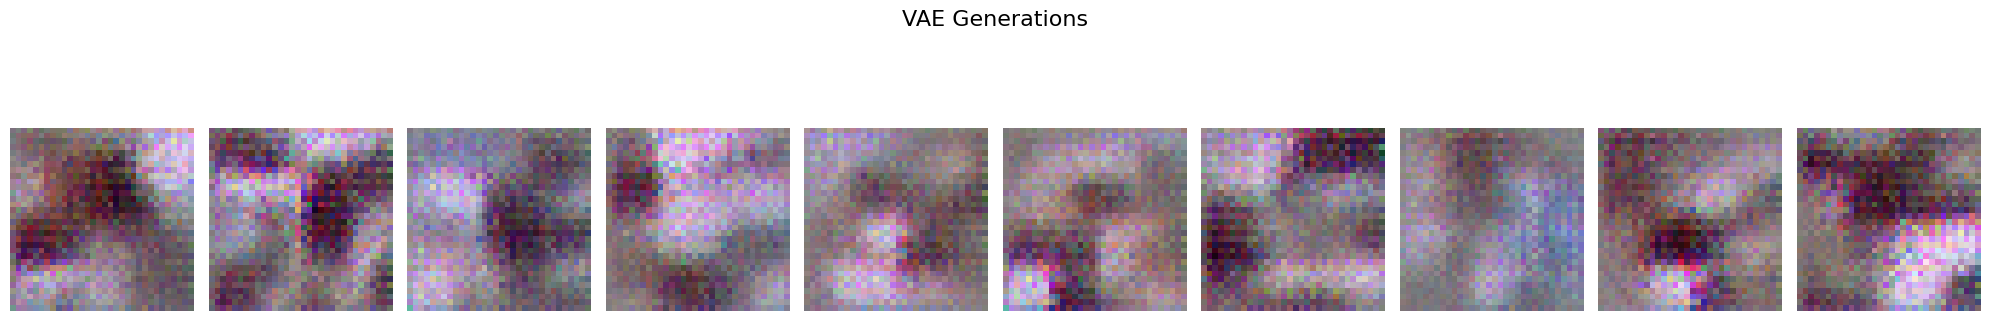

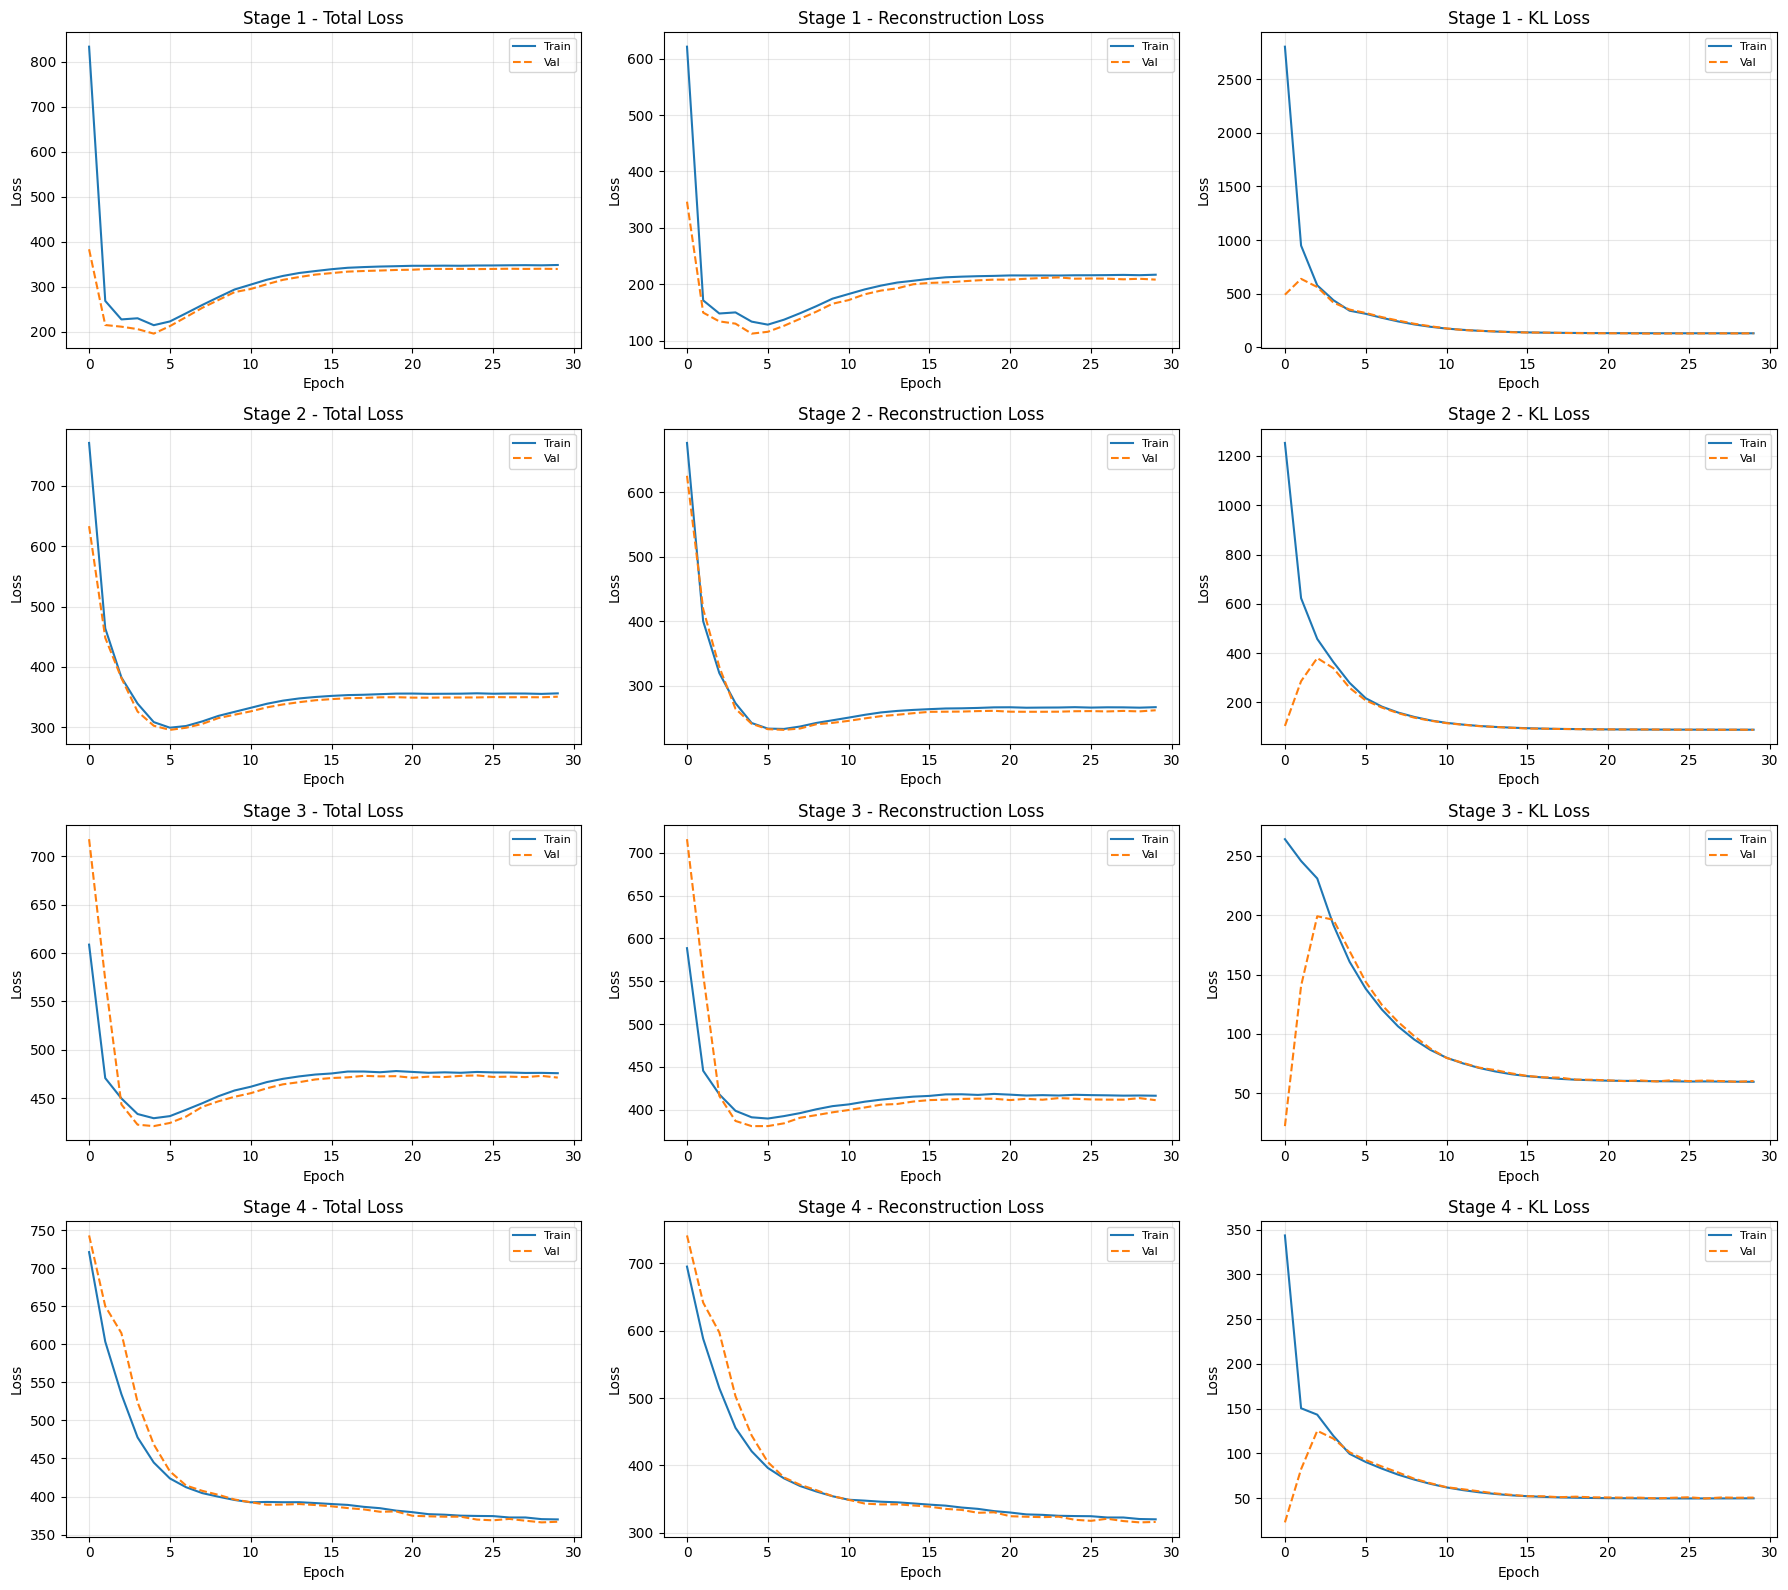


Final stage metrics:
  Stage 1: total=348.75, recon=216.89, kl=131.96
  Stage 2: total=356.06, recon=266.56, kl=89.57
  Stage 3: total=475.72, recon=416.18, kl=59.59
  Stage 4: total=369.92, recon=320.11, kl=49.84


In [5]:
# Cell 5: Visualisation

# Function to convert tanh outputs back to [0, 1] range for display
def tanh_display(img):
    return (np.clip(img, -1, 1) + 1) / 2

# Reconstructions
test_samples  = x_test[:10]
z_mean, z_log_var, z = vae.encoder.predict(test_samples)
reconstructed = vae.decoder.predict(z, verbose=0)
fig, axes     = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(tanh_display(test_samples[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(tanh_display(reconstructed[i]))
    axes[1, i].axis('off')
axes[0, 4].set_title('Originals', loc='center', fontsize=16)
axes[1, 5].set_title('Reconstructed', loc='center', fontsize=16)
plt.tight_layout()
plt.show()

# Generations
z = np.random.normal(
    size=(10, BOTTLENECK_DIM, BOTTLENECK_DIM, LATENT_DIM)
)
generated = vae.decoder.predict(z)
fig, axes     = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(tanh_display(generated[i]))
    ax.axis('off')
plt.suptitle('VAE Generations', fontsize=16)
plt.tight_layout()
plt.show()

# Loss curves for each stage: total, recon, and KL
n_stages = len(histories)
fig, axes = plt.subplots(n_stages, 3, figsize=(18, 4 * n_stages))
panels = [
    ('Total Loss', 'loss', 'val_loss'),
    ('Reconstruction Loss', 'recon_loss', 'val_recon_loss'),
    ('KL Loss', 'kl_loss', 'val_kl_loss'),
]
for stage_idx, hist in enumerate(histories):
    for col_idx, (title, train_key, val_key) in enumerate(panels):
        ax = axes[stage_idx, col_idx] if n_stages > 1 else axes[col_idx]
        ax.set_title(f"Stage {stage_idx + 1} - {title}")
        if train_key in hist:
            ax.plot(hist[train_key], label='Train')
        if val_key in hist:
            ax.plot(hist[val_key], linestyle='--', label='Val')
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final metrics summary
print('\nFinal stage metrics:')
for i, hist in enumerate(histories):
    print(f'  Stage {i+1}: total={hist["loss"][-1]:.2f}, recon={hist["recon_loss"][-1]:.2f}, kl={hist["kl_loss"][-1]:.2f}')

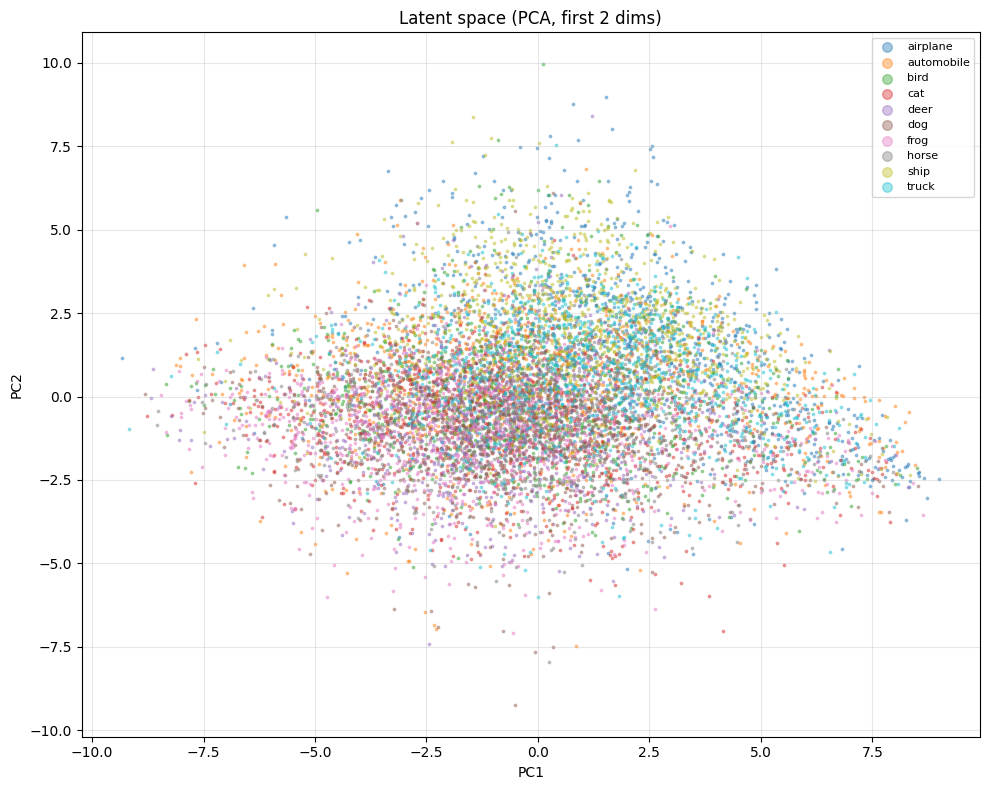

Model: "vae_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_L4 (Functional)         │ ((None, 4, 4, 32),     │       106,656 │
│                                 │ (None, 4, 4, 32),      │               │
│                                 │ (None, 4, 4, 32))      │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_8 (InputLayer) │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_14 (Conv2D)         │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_20     │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_15 (Conv2D)         │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_21     │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_16 (Conv2D)         │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_22     │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_17 (Conv2D)         │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_23     │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Conv2D)            │ (None, 4, 4, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Conv2D)         │ (None, 4, 4, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ sampling_4 (Sampling)      │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_L4 (Functional)         │ (None, 32, 32, 3)      │       135,267 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_9 (InputLayer) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose_10        │ (None, 4, 4, 128)      │        36,992 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_24     │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose_11        │ (None, 8, 8, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_25     │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose_12        │ (None, 16, 16, 32)     │        18,46

 Total params: 629,256 (2.40 MB)

 Trainable params: 193,664 (756.50 KB)

 Non-trainable params: 48,259 (188.51 KB)

 Optimizer params: 387,333 (1.48 MB)

In [ ]:
# Cell 6: Latent Space Visualisation
# Visualise the first two PCA dimensions of the latent space, coloured by class
# A well-trained VAE should show smooth, overlapping blobs (not tight clusters)

(_, y_test_labels) = keras.datasets.cifar10.load_data()[1]

z_means, _, _ = encoder.predict(x_test, verbose=0)

# flatten spatial latent  - vector per sample
z_means_flat = z_means.reshape(z_means.shape[0], -1)

# Manual PCA using NumPy
z_centred            = z_means_flat - z_means_flat.mean(axis=0)
cov                  = np.cov(z_centred, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov)
# eigh returns ascending order — take the last 2 (largest variance)
top2                 = eigenvecs[:, -2:][:, ::-1]
z_2d                 = z_centred @ top2

labels = y_test_labels.flatten()

cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=cifar10_classes[cls])

plt.title('Latent space (PCA, first 2 dims)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4, loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

vae.summary(expand_nested=True)